# Proyecto: Impacto de la Inteligencia Artificial en el Empleo (Hacia 2030)

## Problemática

La rápida adopción de la Inteligencia Artificial (IA) está transformando los entornos laborales. Si bien optimiza la productividad y la eficiencia, también genera una profunda incertidumbre sobre el futuro del empleo y la automatización de funciones.

El desafío principal radica en que **el impacto no es uniforme**: varía significativamente según el perfil de cada ocupación.

## Pregunta orientadora

¿Cómo podría impactar la adopción de la Inteligencia Artificial en las distintas ocupaciones laborales hacia el año 2030 de acuerdo con las variables contenidas en el dataset seleccionado?

## El Desafío Analítico

La problemática de este proyecto consiste en **identificar y analizar qué factores clave determinan el nivel de riesgo de transformación laboral** frente a la IA hacia el año 2030.

Para resolverlo, utilizaremos el conjunto de datos "AI Impact on Jobs 2030" con el fin de evaluar cómo interactúan las siguientes variables:

- **Exposición tecnológica** y probabilidad de automatización.
- **Nivel educacional** requerido.
- **Experiencia laboral** previa.

**Objetivo del Notebook:** Construir y ejecutar el pipeline completo de preprocesamiento para dejar el dataset listo para modelado.

### Información de atributos del dataset

**1. Variables principales**
- `Job_Title` — Categórica nominal. Nombre de la ocupación (20 categorías).
- `Average_Salary` — Numérica (int). Salario promedio anual.
- `Years_Experience` — Numérica (int). Años de experiencia laboral.
- `Education_Level` — Categórica ordinal. Nivel educativo (High School, Bachelor's, Master's, PhD).

**2. Variables relacionadas con IA y automatización**
- `AI_Exposure_Index` — Numérica float [0–1]. Nivel de exposición del trabajo a la IA.
- `Tech_Growth_Factor` — Numérica float. Tasa de crecimiento tecnológico del sector.
- `Automation_Probability_2030` — Numérica float [0–1]. Probabilidad estimada de automatización hacia 2030.
- `Risk_Category` — Categórica ordinal. Nivel de riesgo: Low, Medium, High.

**3. Variables de habilidades (skills)**
- `Skill_1` a `Skill_10` — Numéricas float [0–1]. Niveles de dominio en distintas habilidades (normalizadas en origen).

In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Agregar src al path de Python
sys.path.append(os.path.abspath("../src"))

from data_loading import cargar_datos
from preprocessing import (
    limpiar_datos,
    encoding_categorico,
    crear_features,
    normalizar_datos,
    validar_datos,
    exportar_dataset
)

print("Módulos cargados correctamente.")

Módulos cargados correctamente.


---

## 1. Carga y Exploración Inicial

Se carga el dataset y se realiza un diagnóstico inicial antes de aplicar cualquier transformación: dimensiones, tipos de datos, valores nulos y duplicados.

In [3]:
ds = cargar_datos('../data/raw/AI_Impact_on_Jobs_2030.csv')

print("=== DIAGNÓSTICO INICIAL ===")
print(f"\nDimensiones: {ds.shape[0]} filas × {ds.shape[1]} columnas")
print("\n--- Información general ---")
ds.info()

Datos cargados: 3000 filas y 18 columnas.
=== DIAGNÓSTICO INICIAL ===

Dimensiones: 3000 filas × 18 columnas

--- Información general ---
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   str    
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   str    
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   str    
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4

In [4]:
print("--- Estadísticas descriptivas ---")
display(ds.describe())

print("\n--- Valores nulos por columna ---")
print(ds.isna().sum())

print(f"\n--- Registros duplicados: {ds.duplicated().sum()} ---")

print("\n--- Primeras 5 filas ---")
display(ds.head())

--- Estadísticas descriptivas ---


,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- Valores nulos por columna ---
Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64

--- Registros duplicados: 0 ---

--- Primeras 5 filas ---


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


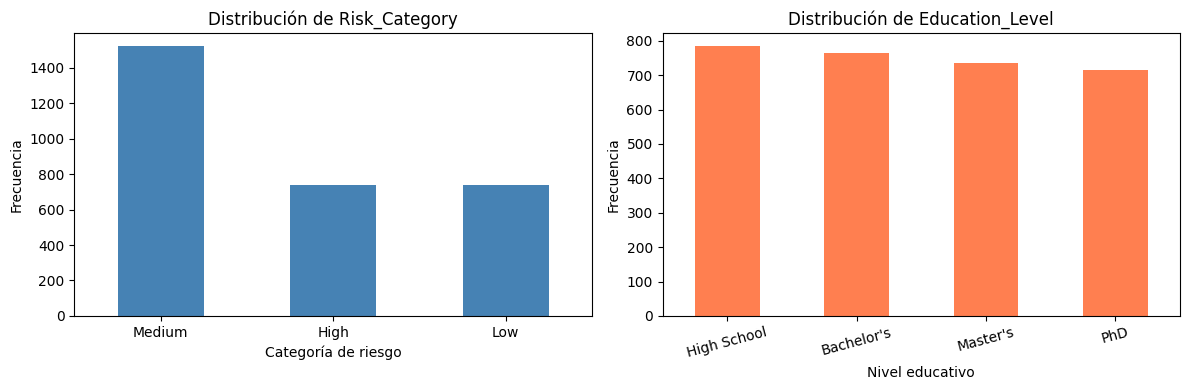

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ds['Risk_Category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Risk_Category')
axes[0].set_xlabel('Categoría de riesgo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

ds['Education_Level'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribución de Education_Level')
axes[1].set_xlabel('Nivel educativo')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---

## 2. Limpieza de Datos

Se aplica `limpiar_datos()` del módulo `src/preprocessing.py`. Esta función:

- Elimina registros duplicados con `drop_duplicates()`.
- Imputa valores nulos numéricos con la **mediana** de cada columna (método robusto ante outliers).
- Imputa valores nulos categóricos con la **moda** de cada columna.

Se muestran los conteos antes y después para evidenciar el efecto de la limpieza.

In [6]:
nulos_antes = ds.isna().sum().sum()
duplicados_antes = ds.duplicated().sum()
filas_antes = len(ds)

print(f"Antes de limpiar — nulos: {nulos_antes}, duplicados: {duplicados_antes}, filas: {filas_antes}")

ds = limpiar_datos(ds)

nulos_despues = ds.isna().sum().sum()
duplicados_despues = ds.duplicated().sum()
filas_despues = len(ds)

print(f"Después de limpiar — nulos: {nulos_despues}, duplicados: {duplicados_despues}, filas: {filas_despues}")
print(f"\nFilas eliminadas: {filas_antes - filas_despues}")
print(f"Nulos imputados: {nulos_antes - nulos_despues}")

Antes de limpiar — nulos: 0, duplicados: 0, filas: 3000
Después de limpiar — nulos: 0, duplicados: 0, filas: 3000

Filas eliminadas: 0
Nulos imputados: 0


---

## 3. Transformación y Encoding

Se aplica `encoding_categorico()` del módulo `src/preprocessing.py`. Las decisiones técnicas son:

| Variable | Tipo | Método | Justificación |
|---|---|---|---|
| `Job_Title` | Nominal (sin orden) | One-Hot Encoding (`pd.get_dummies`) | No existe jerarquía entre ocupaciones; OHE evita introducir un orden artificial |
| `Education_Level` | Ordinal (con orden) | Encoding ordinal con mapeo explícito | Existe orden lógico: High School < Bachelor's < Master's < PhD; se preserva la relación jerárquica |
| `Risk_Category` | Ordinal (con orden) | Encoding ordinal con mapeo explícito | Existe orden semántico: Low < Medium < High; preservarlo permite a los modelos explotar esa relación |

In [7]:
shape_antes = ds.shape
print(f"Shape antes del encoding: {shape_antes}")

ds = encoding_categorico(ds)

print(f"Shape después del encoding: {ds.shape}")
print(f"Columnas nuevas: {ds.shape[1] - shape_antes[1]}")

print(f"\nEducation_Level (ordinal) — valores únicos: {sorted(ds['Education_Level'].unique())}")
print(f"Risk_Category (ordinal) — valores únicos: {sorted(ds['Risk_Category'].unique())}")

job_cols = [c for c in ds.columns if c.startswith('Job_Title_')]
print(f"\nColumnas OHE generadas para Job_Title ({len(job_cols)} categorías):")
print(job_cols)

Shape antes del encoding: (3000, 18)
Shape después del encoding: (3000, 37)
Columnas nuevas: 19

Education_Level (ordinal) — valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Risk_Category (ordinal) — valores únicos: [np.int64(0), np.int64(1), np.int64(2)]

Columnas OHE generadas para Job_Title (20 categorías):
['Job_Title_AI Engineer', 'Job_Title_Chef', 'Job_Title_Construction Worker', 'Job_Title_Customer Support', 'Job_Title_Data Scientist', 'Job_Title_Doctor', 'Job_Title_Financial Analyst', 'Job_Title_Graphic Designer', 'Job_Title_HR Specialist', 'Job_Title_Lawyer', 'Job_Title_Marketing Manager', 'Job_Title_Mechanic', 'Job_Title_Nurse', 'Job_Title_Research Scientist', 'Job_Title_Retail Worker', 'Job_Title_Security Guard', 'Job_Title_Software Engineer', 'Job_Title_Teacher', 'Job_Title_Truck Driver', 'Job_Title_UX Researcher']


---

## 4. Feature Engineering

Se aplica `crear_features()` del módulo `src/preprocessing.py`. Esta función genera dos nuevas variables:

- **`Skill_Index`:** promedio de `Skill_1` a `Skill_10`. Captura el perfil general de habilidades con una variable agregada, reduciendo dimensionalidad sin perder información de conjunto.
- **`High_Risk`:** variable objetivo binaria. Valor 1 si `Automation_Probability_2030 > 0.7`, 0 en caso contrario. El umbral del 70% corresponde a la clasificación de riesgo alto adoptada en la literatura sobre automatización laboral.

In [8]:
ds = crear_features(ds)

print("Nuevas variables creadas:")

print(f"\nHigh_Risk (Automation_Probability_2030 > 0.7):")
print(ds['High_Risk'].value_counts())
print(f"  Porcentaje de alto riesgo: {ds['High_Risk'].mean()*100:.1f}%")

print(f"\nSkill_Index (promedio Skill_1 a Skill_10):")
print(ds['Skill_Index'].describe().round(3))

Nuevas variables creadas:

High_Risk (Automation_Probability_2030 > 0.7):
High_Risk
0    2260
1     740
Name: count, dtype: int64
  Porcentaje de alto riesgo: 24.7%

Skill_Index (promedio Skill_1 a Skill_10):
count    3000.000
mean        0.498
std         0.090
min         0.222
25%         0.438
50%         0.500
75%         0.556
max         0.796
Name: Skill_Index, dtype: float64


---

## 5. Normalización

Se aplica `normalizar_datos()` del módulo `src/preprocessing.py`. Las variables con escalas distintas a [0,1] se normalizan con `MinMaxScaler` para garantizar que ninguna variable domine por su magnitud.

**Variables normalizadas:** `Average_Salary`, `Years_Experience`, `Tech_Growth_Factor`, `Education_Level`, `Risk_Category`.

**Variables que ya estaban en [0,1]** (no se tocan): `AI_Exposure_Index`, `Automation_Probability_2030`, `Skill_1`–`Skill_10`, `Skill_Index`, `High_Risk`, columnas `Job_Title_*`.

**Elección de MinMaxScaler sobre StandardScaler:** el dataset no contiene outliers extremos y se quiere mantener los valores en el rango [0,1] para consistencia con las demás variables.

In [9]:
cols_a_ver = ['Average_Salary', 'Years_Experience', 'Tech_Growth_Factor']

print("Antes de normalizar:")
display(ds[cols_a_ver].describe().round(2))

ds = normalizar_datos(ds)

print("\nDespués de normalizar:")
display(ds[cols_a_ver].describe().round(4))

Antes de normalizar:


,Average_Salary,Years_Experience,Tech_Growth_Factor
count,3000.00,3000.00,3000.00
mean,89372.28,14.68,1.00
std,34608.09,8.74,0.29
min,30030.00,0.00,0.50
25%,58640.00,7.00,0.74
50%,89318.00,15.00,1.00
75%,119086.50,22.00,1.24
max,149798.00,29.00,1.50



Después de normalizar:


,Average_Salary,Years_Experience,Tech_Growth_Factor
count,3000.0000,3000.0000,3000.0000
mean,0.4955,0.5061,0.4953
std,0.2890,0.3014,0.2877
min,0.0000,0.0000,0.0000
25%,0.2389,0.2414,0.2400
50%,0.4950,0.5172,0.5000
75%,0.7436,0.7586,0.7400
max,1.0000,1.0000,1.0000


---

## 6. Validación

Se verifican las condiciones de calidad del dataset final:

- **Casos normales:** ausencia de nulos y duplicados.
- **Casos límite:** rangos esperados para variables clave.
- **Tipos de datos:** variables numéricas con tipo correcto tras normalización.

Cada validación muestra evidencia explícita del resultado.

In [10]:
print("=== VALIDACIONES DEL DATASET FINAL ===")
print(f"\nDimensiones: {ds.shape[0]} filas × {ds.shape[1]} columnas")
print(f"Nulos totales: {ds.isna().sum().sum()}")
print(f"Duplicados totales: {ds.duplicated().sum()}")

# Validaciones de rango
assert ds['AI_Exposure_Index'].between(0, 1).all(), "❌ AI_Exposure_Index fuera de [0,1]"
print("\n✅ AI_Exposure_Index en rango [0,1]")

assert ds['Automation_Probability_2030'].between(0, 1).all(), "❌ Automation_Probability_2030 fuera de [0,1]"
print("✅ Automation_Probability_2030 en rango [0,1]")

assert ds['High_Risk'].isin([0, 1]).all(), "❌ High_Risk tiene valores distintos de 0 y 1"
print("✅ High_Risk solo contiene 0 y 1")

assert ds['Education_Level'].between(0, 1).all(), "❌ Education_Level fuera de [0,1] tras normalización"
print("✅ Education_Level en rango [0,1] (normalizado)")

assert ds['Risk_Category'].between(0, 1).all(), "❌ Risk_Category fuera de [0,1] tras normalización"
print("✅ Risk_Category en rango [0,1] (normalizado)")

assert ds['Average_Salary'].between(0, 1).all(), "❌ Average_Salary fuera de [0,1] tras normalización"
print("✅ Average_Salary en rango [0,1] (normalizado)")

# Validación de tipos
assert ds['Average_Salary'].dtype in ['float64', 'float32'], "❌ Average_Salary debe ser float"
print("✅ Average_Salary tipo float")

# Validación de columnas OHE
job_cols = [c for c in ds.columns if c.startswith('Job_Title_')]
assert len(job_cols) == 20, f"❌ Se esperaban 20 columnas Job_Title_*, se encontraron {len(job_cols)}"
print(f"✅ Columnas OHE Job_Title_*: {len(job_cols)} (correcto)")

# Validación del módulo
print("")
validar_datos(ds)

=== VALIDACIONES DEL DATASET FINAL ===

Dimensiones: 3000 filas × 39 columnas
Nulos totales: 0
Duplicados totales: 0

✅ AI_Exposure_Index en rango [0,1]
✅ Automation_Probability_2030 en rango [0,1]
✅ High_Risk solo contiene 0 y 1
✅ Education_Level en rango [0,1] (normalizado)
✅ Risk_Category en rango [0,1] (normalizado)
✅ Average_Salary en rango [0,1] (normalizado)
✅ Average_Salary tipo float
✅ Columnas OHE Job_Title_*: 20 (correcto)

✅ Validaciones OK


---

## 7. Exportación

Se exporta el dataset procesado a `data/processed/AI_Impact_on_Jobs_2030_clean.csv` usando `exportar_dataset()` del módulo `src/preprocessing.py`.

In [11]:
exportar_dataset(ds)


=== DATASET FINAL ===
Shape: (3000, 39)

Columnas: ['Average_Salary', 'Years_Experience', 'Education_Level', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Job_Title_AI Engineer', 'Job_Title_Chef', 'Job_Title_Construction Worker', 'Job_Title_Customer Support', 'Job_Title_Data Scientist', 'Job_Title_Doctor', 'Job_Title_Financial Analyst', 'Job_Title_Graphic Designer', 'Job_Title_HR Specialist', 'Job_Title_Lawyer', 'Job_Title_Marketing Manager', 'Job_Title_Mechanic', 'Job_Title_Nurse', 'Job_Title_Research Scientist', 'Job_Title_Retail Worker', 'Job_Title_Security Guard', 'Job_Title_Software Engineer', 'Job_Title_Teacher', 'Job_Title_Truck Driver', 'Job_Title_UX Researcher', 'Skill_Index', 'High_Risk']

Tipos:
 Average_Salary                   float64
Years_Experience                 float64
Education_Level                  float64
AI